In [1]:
import time
import numpy as np
import pandas as pd
import tensorflow as tf
from matplotlib import pyplot as plt
from sklearn.metrics import (
    accuracy_score,
    recall_score,
    f1_score,
    roc_auc_score,
    precision_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
)

## Preprocesado de datos

In [2]:
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()

x_train = x_train / 255.0
x_test = x_test / 255.0

x_train = x_train[..., None]
x_test = x_test[..., None]

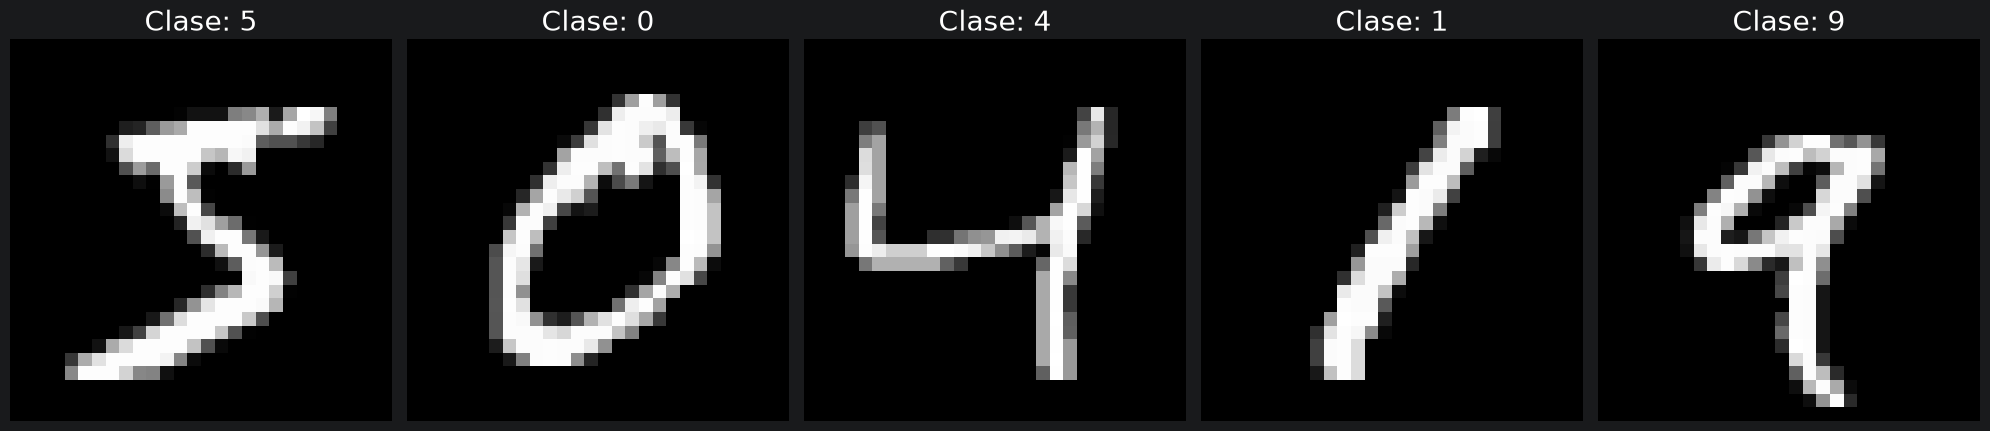

In [3]:
fig, axes = plt.subplots(1, 5, figsize=(20, 5))

for i, image in enumerate(x_train[:5]):
    axes[i].imshow(image, cmap="gray")
    axes[i].set_title(f"Clase: {y_train[i]}", size=20)
    axes[i].axis("off")

plt.tight_layout()
plt.show()

## Funciones auxiliares

In [14]:
def entrenar_evaluar(model, x_tr, y_tr, x_te, y_te, epochs=6):
    t_ini = time.time() # calculamos el tiempo exacto del entrenamiento
    h = model.fit(x_tr, y_tr, epochs=epochs, batch_size=128, validation_split=0.15)
    t_total = time.time() - t_ini

    prob_tr = model.predict(x_tr, batch_size=128) # obtenemos las salidas del modelo (una probabilidad)
    prob_te = model.predict(x_te, batch_size=128)
    pred_tr = np.argmax(prob_tr, axis=1) # la predicccion es la salida con mayor probabilidad
    pred_te = np.argmax(prob_te, axis=1)

    acc_tr = accuracy_score(y_tr, pred_tr) # calculamos el accuracy
    acc_te = accuracy_score(y_te, pred_te)

    num_err_tr = int(np.sum(pred_tr.ravel() != y_tr))
    num_err_te = int(np.sum(pred_te.ravel() != y_te))

    prec_te = precision_score(y_te, pred_te, average="macro")
    rec_te = recall_score(y_te, pred_te, average="macro")
    f1_te = f1_score(y_te, pred_te, average="macro")
    auc_te = roc_auc_score(y_te, prob_te, multi_class="ovr")

    cm_tr = confusion_matrix(y_tr, pred_tr) # creamos las matrices de confusion
    cm_te = confusion_matrix(y_te, pred_te)

    metricas = {
        "tiempo_entrenamiento(s)": round(t_total, 2),
        "train_accuracy": round(acc_tr, 4),
        "test_accuracy": round(acc_te, 4),
        "errores_train": f"{num_err_tr}/{len(y_tr)}",
        "errores_test": f"{num_err_te}/{len(y_te)}",
        "precision": round(prec_te, 4),
        "recall": round(rec_te, 4),
        "f1_score": round(f1_te, 4),
        "auc_roc": round(auc_te, 4),
    }

    return metricas, model, cm_tr, cm_te, pred_te, h

def resumen(cm_tr, cm_te, h):
    fig, axes = plt.subplots(2, 2, figsize=(12, 9))
    clases = ["0", "1", "2", "3", "4", "5", "6", "7", "8", "9"  ]

    axes[0, 0].set_title("train cofusion matrix")
    disp_tr = ConfusionMatrixDisplay(cm_tr, display_labels=clases)
    disp_tr.plot(ax=axes[0, 0])

    axes[0, 1].set_title("test confusion matrix")
    disp_te = ConfusionMatrixDisplay(cm_te, display_labels=clases)
    disp_te.plot(ax=axes[0, 1])

    axes[1, 0].plot(h.history["loss"], label="loss", color="b")
    axes[1, 0].plot(h.history["val_loss"], label="validation_loss", color="orange")
    axes[1, 0].set_title("loss curves")
    axes[1, 0].set_xlabel("epochs")
    axes[1, 0].set_ylabel("loss")
    axes[1, 0].legend()
    axes[1, 0].grid(True)

    axes[1, 1].plot(h.history["accuracy"], label="train_accuracy", color="green")
    axes[1, 1].plot(h.history["val_accuracy"], label="validation_accuracy", color="yellow")
    axes[1, 1].set_title("accuracy curves")
    axes[1, 1].set_xlabel("epochs")
    axes[1, 1].set_ylabel("accuracy")
    axes[1, 1].set_ylim(0.8, 1.0)
    axes[1, 1].legend()
    axes[1, 1].grid(True)

    plt.tight_layout()
    plt.show()

In [5]:
metricas = pd.DataFrame()

## Desarrollo de modelos

Para cada experimento dejaremos fijos los valores de épocas (6), optimizador (Adam), tamaño de lote (128) y tasa de aprendizaje (0.001). Además hemos incluido un conjunto de validación para ir comprobando como avanza el entrenamiento. Usaremos un 15% del conjunto de entrenamiento como conjunto de validación.

### Experimento 0

Vamos a crear la CNN más básica con 1 capa convolucional (32 kernels de 3x3), 1 capa MaxPooling2D (2x2), un aplanado (flatten) y 1 capa densa de 128 neuronas antes de la salida de 10 clases. Este será nuestro baseline y veremos si los cambios de los siguientes experimentos mejoran o empeoran el modelo.


Epoch 1/6
797/797 ━━━━━━━━━━━━━━━━━━━━ 12s 14ms/step - accuracy: 0.9421 - loss: 0.1978 - val_accuracy: 0.9772 - val_loss: 0.0812
Epoch 2/6
797/797 ━━━━━━━━━━━━━━━━━━━━ 9s 12ms/step - accuracy: 0.9809 - loss: 0.0639 - val_accuracy: 0.9811 - val_loss: 0.0661
Epoch 3/6
797/797 ━━━━━━━━━━━━━━━━━━━━ 8s 10ms/step - accuracy: 0.9876 - loss: 0.0419 - val_accuracy: 0.9841 - val_loss: 0.0606
Epoch 4/6
797/797 ━━━━━━━━━━━━━━━━━━━━ 9s 11ms/step - accuracy: 0.9919 - loss: 0.0280 - val_accuracy: 0.9850 - val_loss: 0.0612
Epoch 5/6
797/797 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - accuracy: 0.9948 - loss: 0.0189 - val_accuracy: 0.9854 - val_loss: 0.0647
Epoch 6/6
797/797 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - accuracy: 0.9963 - loss: 0.0137 - val_accuracy: 0.9841 - val_loss: 0.0686
938/938 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 


,tiempo_entrenamiento(s),train_accuracy,test_accuracy,errores_train,errores_test,precision,recall,f1_score,auc_roc
0,52.59,0.9945,0.9833,329/60000,167/10000,0.9832,0.9832,0.9832,0.9998


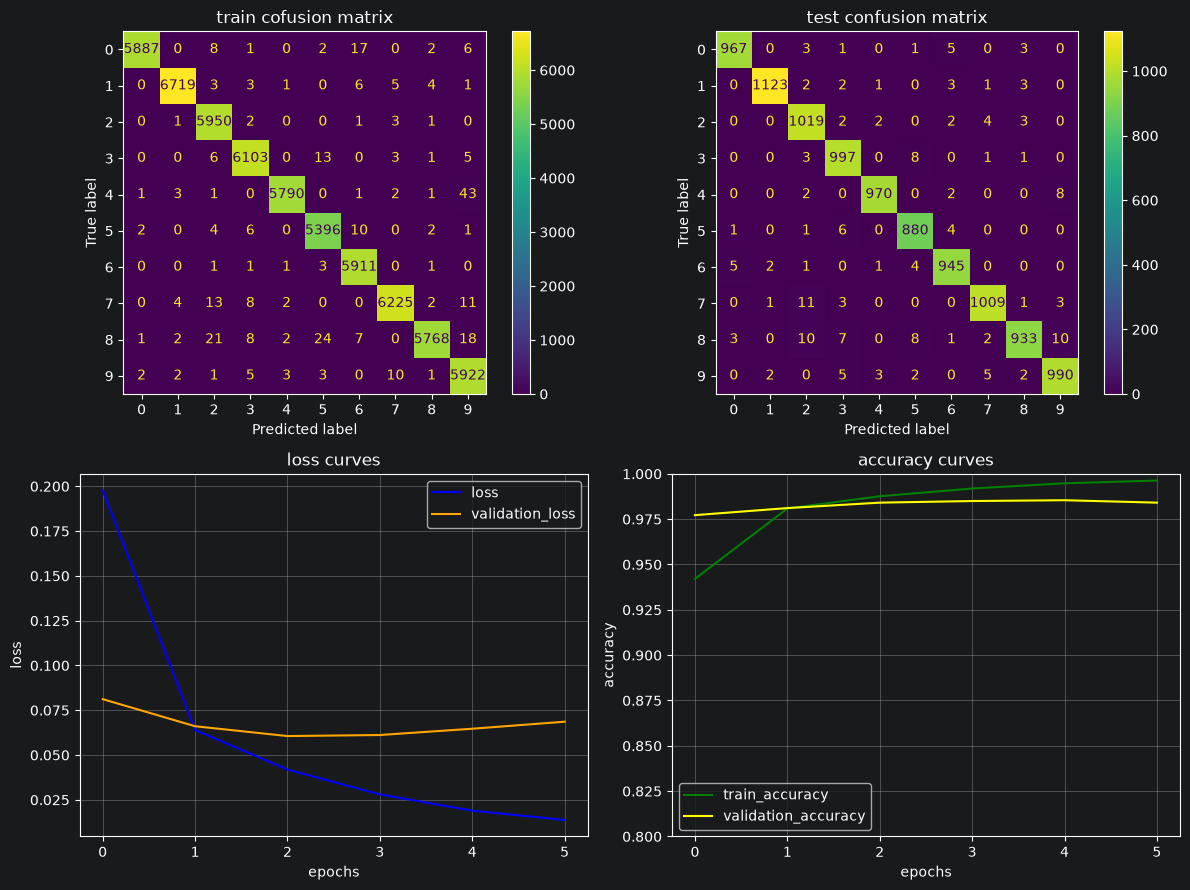

In [6]:
tf.keras.backend.clear_session()
tf.keras.utils.set_random_seed(42)

model = tf.keras.models.Sequential([
    tf.keras.layers.Input(shape=(28, 28, 1)),
    tf.keras.layers.Conv2D(32, (3, 3), activation="relu"),
    tf.keras.layers.MaxPooling2D((2, 2)),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(128, activation="relu"),
    tf.keras.layers.Dense(10, activation="softmax"),
])

model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

met0, mod0, cm_tr0, cm_te0, pred_te0, h0 = entrenar_evaluar(
    model,
    x_tr=x_train,
    y_tr=y_train,
    x_te=x_test,
    y_te=y_test,
)

metricas = pd.concat([metricas, pd.DataFrame([met0])], ignore_index=True)
display(metricas)
resumen(cm_tr0, cm_te0, h0)

## Experimento 1

Epoch 1/6
797/797 ━━━━━━━━━━━━━━━━━━━━ 8s 9ms/step - accuracy: 0.9340 - loss: 0.2286 - val_accuracy: 0.9770 - val_loss: 0.0861
Epoch 2/6
797/797 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - accuracy: 0.9785 - loss: 0.0724 - val_accuracy: 0.9822 - val_loss: 0.0663
Epoch 3/6
797/797 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - accuracy: 0.9855 - loss: 0.0476 - val_accuracy: 0.9838 - val_loss: 0.0588
Epoch 4/6
797/797 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - accuracy: 0.9902 - loss: 0.0337 - val_accuracy: 0.9847 - val_loss: 0.0570
Epoch 5/6
797/797 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - accuracy: 0.9933 - loss: 0.0248 - val_accuracy: 0.9849 - val_loss: 0.0580
Epoch 6/6
797/797 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - accuracy: 0.9952 - loss: 0.0178 - val_accuracy: 0.9848 - val_loss: 0.0591
938/938 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 


,tiempo_entrenamiento(s),train_accuracy,test_accuracy,errores_train,errores_test,precision,recall,f1_score,auc_roc
0,52.59,0.9945,0.9833,329/60000,167/10000,0.9832,0.9832,0.9832,0.9998
1,41.46,0.9946,0.9853,327/60000,147/10000,0.9853,0.9852,0.9852,0.9998


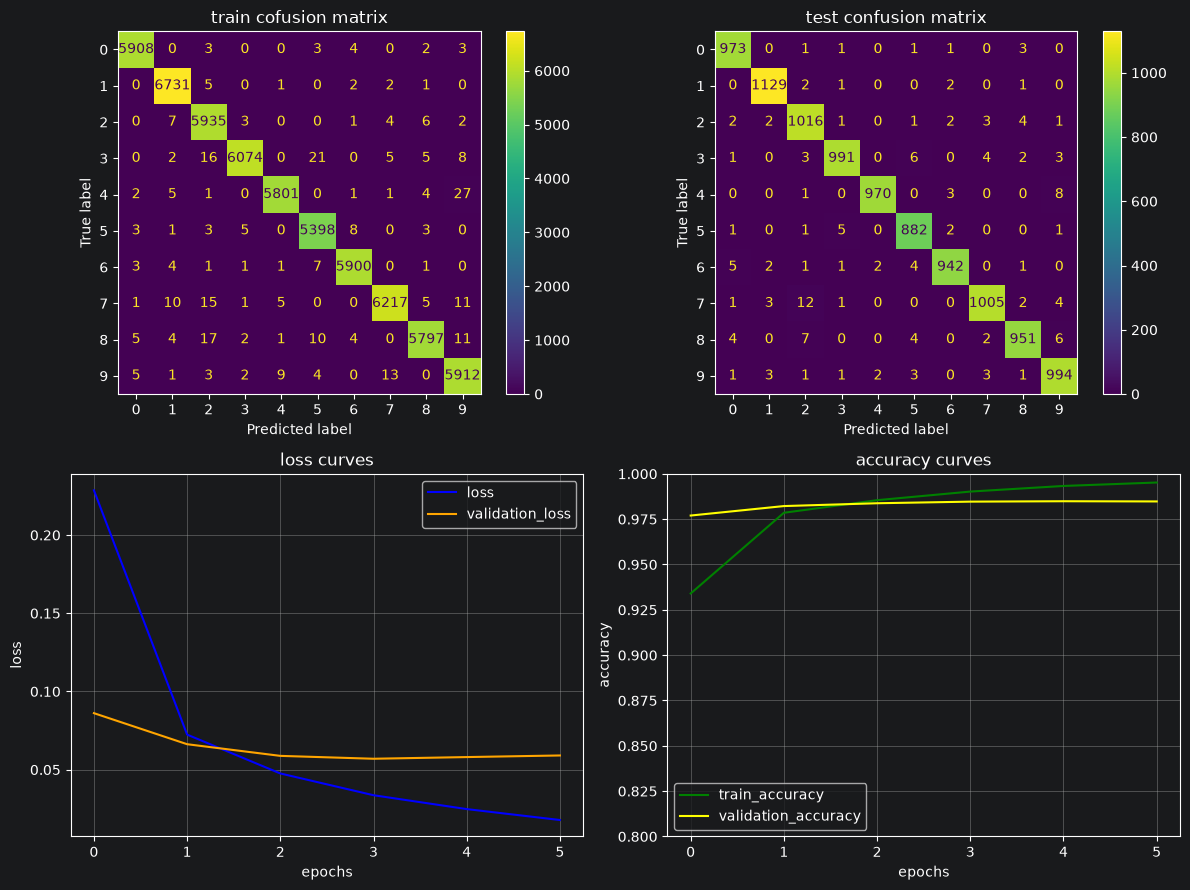

In [7]:
tf.keras.backend.clear_session()
tf.keras.utils.set_random_seed(42)

model = tf.keras.models.Sequential([
    tf.keras.layers.Input(shape=(28, 28, 1)),
    tf.keras.layers.Conv2D(32, (3, 3), activation="relu"),
    tf.keras.layers.AveragePooling2D((2, 2)),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(128, activation="relu"),
    tf.keras.layers.Dense(10, activation="softmax")
])

model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

met1, mod1, cm_tr1, cm_te1, pred_te1, h1 = entrenar_evaluar(
    model,
    x_tr=x_train,
    y_tr=y_train,
    x_te=x_test,
    y_te=y_test,
)

metricas = pd.concat([metricas, pd.DataFrame([met1])], ignore_index=True)
display(metricas)
resumen(cm_tr1, cm_te1, h1)

## Experimento 2

Epoch 1/6
797/797 ━━━━━━━━━━━━━━━━━━━━ 7s 7ms/step - accuracy: 0.9495 - loss: 0.1707 - val_accuracy: 0.9810 - val_loss: 0.0666
Epoch 2/6
797/797 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.9834 - loss: 0.0541 - val_accuracy: 0.9844 - val_loss: 0.0573
Epoch 3/6
797/797 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - accuracy: 0.9895 - loss: 0.0348 - val_accuracy: 0.9854 - val_loss: 0.0572
Epoch 4/6
797/797 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.9934 - loss: 0.0237 - val_accuracy: 0.9873 - val_loss: 0.0551
Epoch 5/6
797/797 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.9950 - loss: 0.0164 - val_accuracy: 0.9874 - val_loss: 0.0517
Epoch 6/6
797/797 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - accuracy: 0.9953 - loss: 0.0142 - val_accuracy: 0.9874 - val_loss: 0.0536
938/938 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 


,tiempo_entrenamiento(s),train_accuracy,test_accuracy,errores_train,errores_test,precision,recall,f1_score,auc_roc
0,52.59,0.9945,0.9833,329/60000,167/10000,0.9832,0.9832,0.9832,0.9998
1,41.46,0.9946,0.9853,327/60000,147/10000,0.9853,0.9852,0.9852,0.9998
2,36.49,0.9950,0.9853,301/60000,147/10000,0.9853,0.9852,0.9852,0.9998


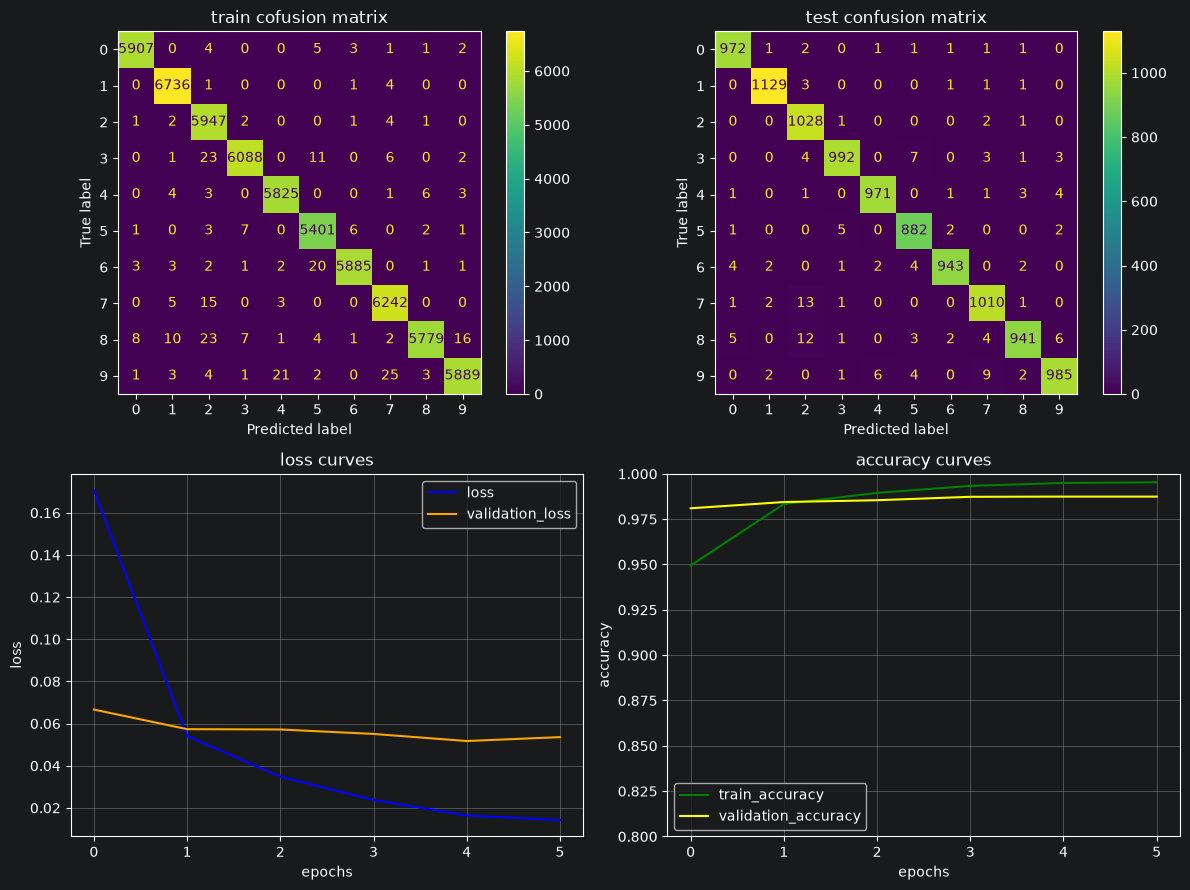

In [8]:
tf.keras.backend.clear_session()
tf.keras.utils.set_random_seed(42)

model = tf.keras.models.Sequential([
    tf.keras.layers.Input(shape=(28, 28, 1)),
    tf.keras.layers.Conv2D(32, (5, 5), activation="relu"),
    tf.keras.layers.MaxPooling2D((2, 2)),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(128, activation="relu"),
    tf.keras.layers.Dense(10, activation="softmax")
])

model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

met2, mod2, cm_tr2, cm_te2, pred_te2, h2 = entrenar_evaluar(
    model,
    x_tr=x_train,
    y_tr=y_train,
    x_te=x_test,
    y_te=y_test,
)

metricas = pd.concat([metricas, pd.DataFrame([met2])], ignore_index=True)
display(metricas)
resumen(cm_tr2, cm_te2, h2)

## Experimento 3

Epoch 1/6
797/797 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.9313 - loss: 0.2379 - val_accuracy: 0.9740 - val_loss: 0.0925
Epoch 2/6
797/797 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.9771 - loss: 0.0763 - val_accuracy: 0.9774 - val_loss: 0.0728
Epoch 3/6
797/797 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.9865 - loss: 0.0461 - val_accuracy: 0.9792 - val_loss: 0.0691
Epoch 4/6
797/797 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.9919 - loss: 0.0295 - val_accuracy: 0.9801 - val_loss: 0.0671
Epoch 5/6
797/797 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.9945 - loss: 0.0194 - val_accuracy: 0.9802 - val_loss: 0.0714
Epoch 6/6
797/797 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.9964 - loss: 0.0131 - val_accuracy: 0.9810 - val_loss: 0.0736
938/938 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 


,tiempo_entrenamiento(s),train_accuracy,test_accuracy,errores_train,errores_test,precision,recall,f1_score,auc_roc
0,52.59,0.9945,0.9833,329/60000,167/10000,0.9832,0.9832,0.9832,0.9998
1,41.46,0.9946,0.9853,327/60000,147/10000,0.9853,0.9852,0.9852,0.9998
2,36.49,0.9950,0.9853,301/60000,147/10000,0.9853,0.9852,0.9852,0.9998
3,26.83,0.9937,0.9816,378/60000,184/10000,0.9814,0.9815,0.9814,0.9998


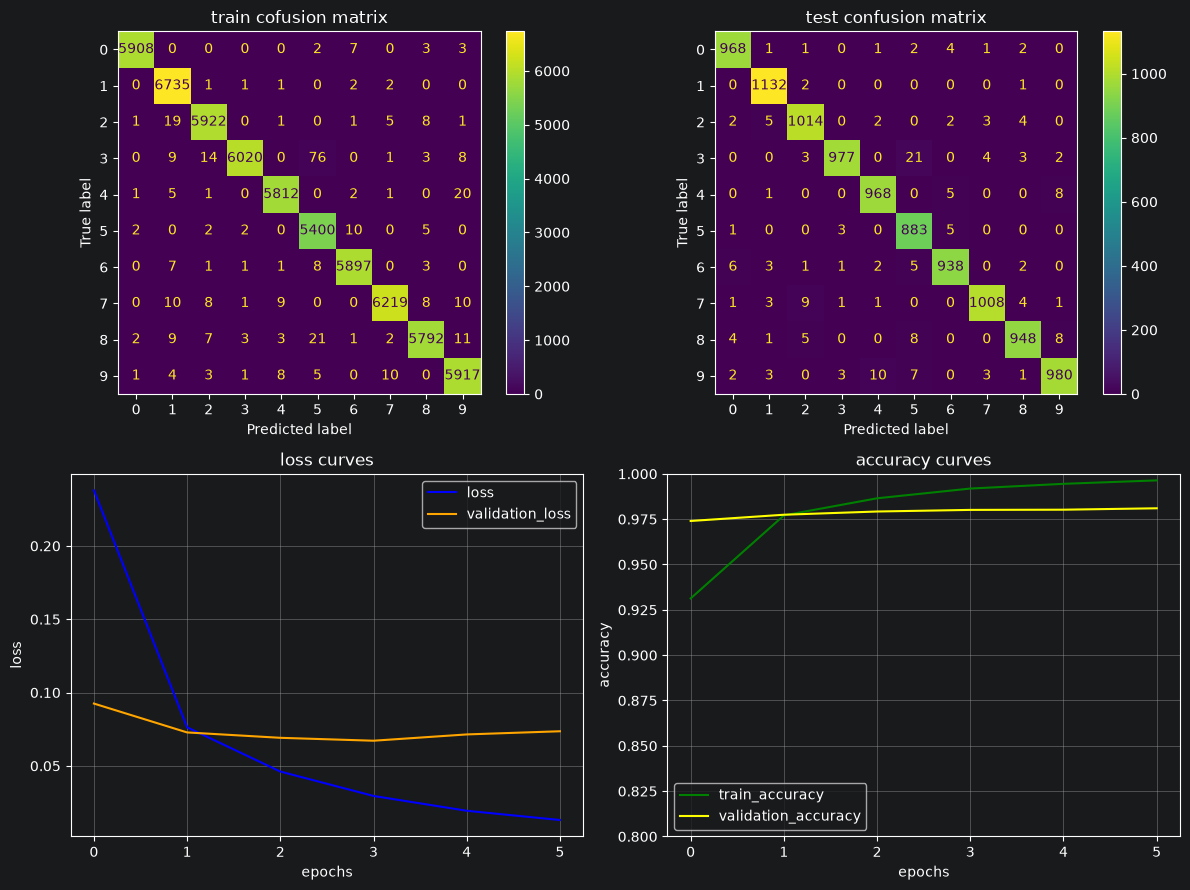

In [9]:
tf.keras.backend.clear_session()
tf.keras.utils.set_random_seed(42)

model = tf.keras.models.Sequential([
    tf.keras.layers.Input(shape=(28, 28, 1)),
    tf.keras.layers.Conv2D(32, (3, 3), strides=2, activation="relu"),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(128, activation="relu"),
    tf.keras.layers.Dense(10, activation="softmax")
])

model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

met3, mod3, cm_tr3, cm_te3, pred_te3, h3 = entrenar_evaluar(
    model,
    x_tr=x_train,
    y_tr=y_train,
    x_te=x_test,
    y_te=y_test,
)

metricas = pd.concat([metricas, pd.DataFrame([met3])], ignore_index=True)
display(metricas)
resumen(cm_tr3, cm_te3, h3)

## Experimento 4

Epoch 1/6
797/797 ━━━━━━━━━━━━━━━━━━━━ 16s 18ms/step - accuracy: 0.9227 - loss: 0.2552 - val_accuracy: 0.9779 - val_loss: 0.0777
Epoch 2/6
797/797 ━━━━━━━━━━━━━━━━━━━━ 14s 18ms/step - accuracy: 0.9690 - loss: 0.1005 - val_accuracy: 0.9792 - val_loss: 0.0770
Epoch 3/6
797/797 ━━━━━━━━━━━━━━━━━━━━ 15s 19ms/step - accuracy: 0.9764 - loss: 0.0761 - val_accuracy: 0.9833 - val_loss: 0.0619
Epoch 4/6
797/797 ━━━━━━━━━━━━━━━━━━━━ 16s 19ms/step - accuracy: 0.9808 - loss: 0.0602 - val_accuracy: 0.9863 - val_loss: 0.0553
Epoch 5/6
797/797 ━━━━━━━━━━━━━━━━━━━━ 15s 19ms/step - accuracy: 0.9841 - loss: 0.0497 - val_accuracy: 0.9861 - val_loss: 0.0581
Epoch 6/6
797/797 ━━━━━━━━━━━━━━━━━━━━ 15s 18ms/step - accuracy: 0.9845 - loss: 0.0463 - val_accuracy: 0.9863 - val_loss: 0.0591
938/938 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 


,tiempo_entrenamiento(s),train_accuracy,test_accuracy,errores_train,errores_test,precision,recall,f1_score,auc_roc
0,52.59,0.9945,0.9833,329/60000,167/10000,0.9832,0.9832,0.9832,0.9998
1,41.46,0.9946,0.9853,327/60000,147/10000,0.9853,0.9852,0.9852,0.9998
2,36.49,0.9950,0.9853,301/60000,147/10000,0.9853,0.9852,0.9852,0.9998
3,26.83,0.9937,0.9816,378/60000,184/10000,0.9814,0.9815,0.9814,0.9998
4,90.20,0.9954,0.9858,277/60000,142/10000,0.9858,0.9857,0.9858,0.9998


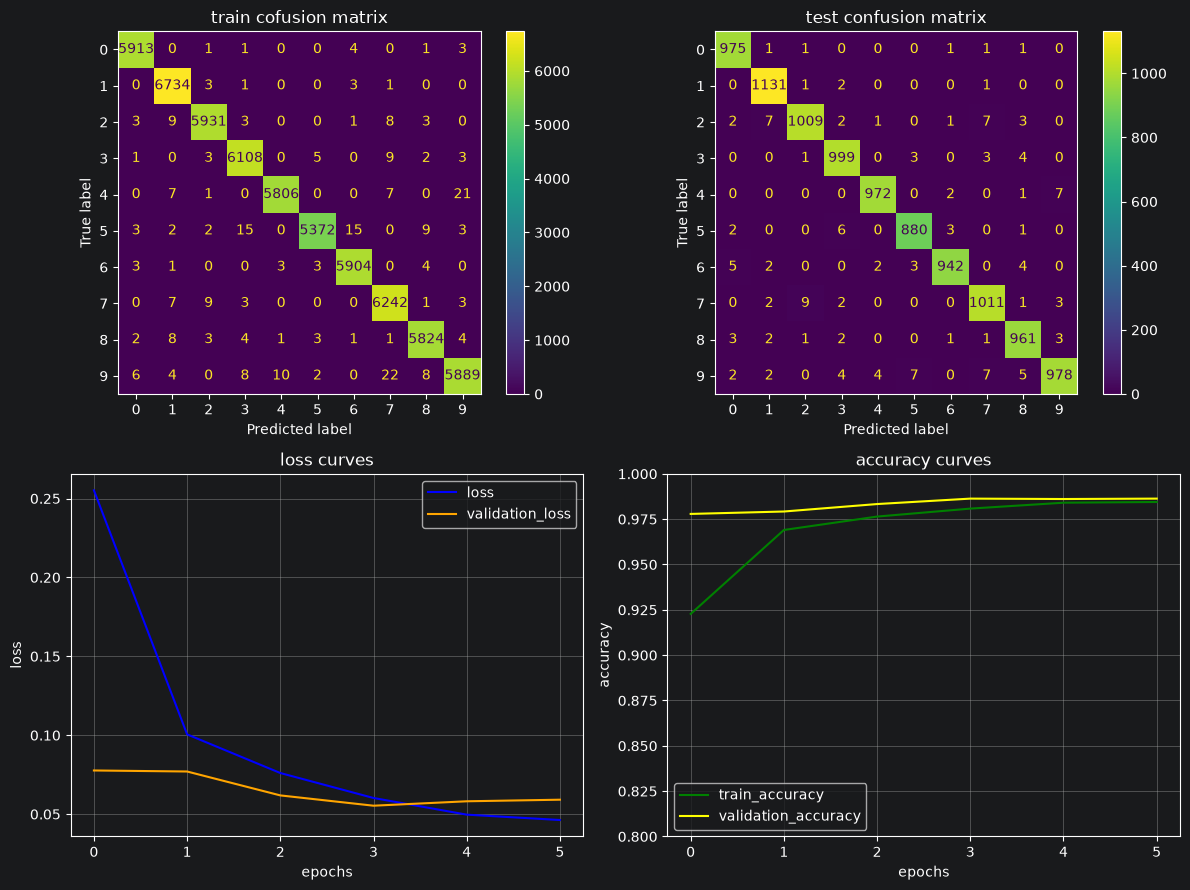

In [10]:
tf.keras.backend.clear_session()
tf.keras.utils.set_random_seed(42)

model = tf.keras.models.Sequential([
    tf.keras.layers.Input(shape=(28, 28, 1)),
    tf.keras.layers.Conv2D(32, (3, 3), activation="relu"),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.MaxPooling2D((2, 2)),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(128, activation="relu"),
    tf.keras.layers.Dropout(0.5),
    tf.keras.layers.Dense(10, activation="softmax")
])

model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

met4, mod4, cm_tr4, cm_te4, pred_te4, h4 = entrenar_evaluar(
    model,
    x_tr=x_train,
    y_tr=y_train,
    x_te=x_test,
    y_te=y_test,
)

metricas = pd.concat([metricas, pd.DataFrame([met4])], ignore_index=True)
display(metricas)
resumen(cm_tr4, cm_te4, h4)

## Modelo final

Epoch 1/3
797/797 ━━━━━━━━━━━━━━━━━━━━ 49s 58ms/step - accuracy: 0.9735 - loss: 0.0907 - val_accuracy: 0.9841 - val_loss: 0.0568
Epoch 2/3
797/797 ━━━━━━━━━━━━━━━━━━━━ 49s 61ms/step - accuracy: 0.9888 - loss: 0.0374 - val_accuracy: 0.9878 - val_loss: 0.0451
Epoch 3/3
797/797 ━━━━━━━━━━━━━━━━━━━━ 46s 58ms/step - accuracy: 0.9908 - loss: 0.0298 - val_accuracy: 0.9869 - val_loss: 0.0493
938/938 ━━━━━━━━━━━━━━━━━━━━ 16s 17ms/step
157/157 ━━━━━━━━━━━━━━━━━━━━ 3s 17ms/step


,tiempo_entrenamiento(s),train_accuracy,test_accuracy,errores_train,errores_test,precision,recall,f1_score,auc_roc
0,52.59,0.9945,0.9833,329/60000,167/10000,0.9832,0.9832,0.9832,0.9998
1,41.46,0.9946,0.9853,327/60000,147/10000,0.9853,0.9852,0.9852,0.9998
2,36.49,0.9950,0.9853,301/60000,147/10000,0.9853,0.9852,0.9852,0.9998
3,26.83,0.9937,0.9816,378/60000,184/10000,0.9814,0.9815,0.9814,0.9998
4,90.20,0.9954,0.9858,277/60000,142/10000,0.9858,0.9857,0.9858,0.9998
5,42.20,0.9951,0.9896,295/60000,104/10000,0.9896,0.9895,0.9895,0.9999
6,94.34,0.9912,0.9865,525/60000,135/10000,0.9866,0.9864,0.9864,0.9998
7,143.85,0.9903,0.9864,582/60000,136/10000,0.9865,0.9862,0.9863,0.9999


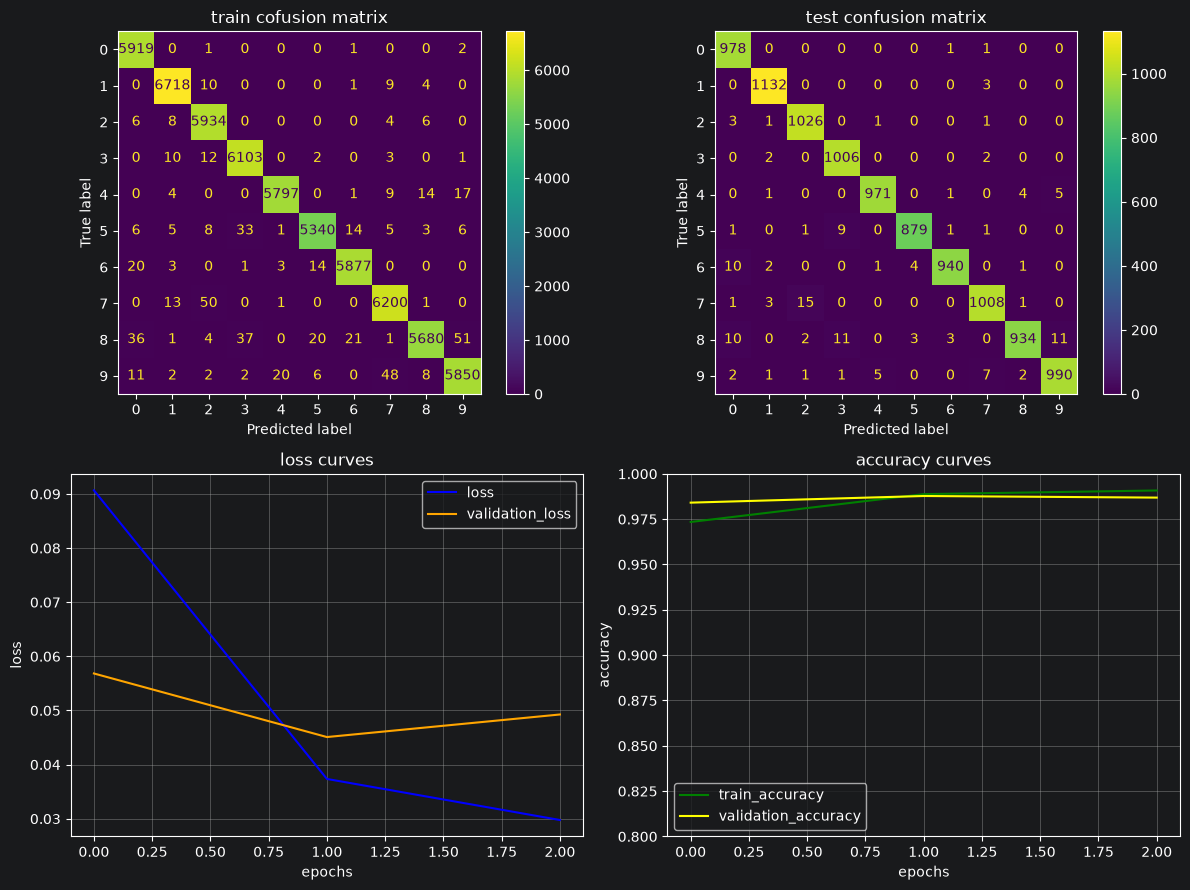

In [15]:
tf.keras.backend.clear_session()
tf.keras.utils.set_random_seed(42)

model = tf.keras.models.Sequential([
    tf.keras.layers.Input(shape=(28, 28, 1)),
    tf.keras.layers.Conv2D(64, (3, 3), activation="relu"),
    tf.keras.layers.Conv2D(64, (3, 3), activation="relu"),
    tf.keras.layers.MaxPooling2D((2, 2)),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Conv2D(128, (3, 3), activation="relu"),
    tf.keras.layers.Conv2D(128, (3, 3), activation="relu"),
    tf.keras.layers.MaxPooling2D((2, 2)),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Conv2D(256, (3, 3), activation="relu"),
    tf.keras.layers.MaxPooling2D((2, 2)),
    tf.keras.layers.Flatten(),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Dense(512, activation="relu"),
    tf.keras.layers.Dense(10, activation="softmax")
])

model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

met5, mod5, cm_tr5, cm_te5, pred_te5, h5 = entrenar_evaluar(
    model,
    x_tr=x_train,
    y_tr=y_train,
    x_te=x_test,
    y_te=y_test,
    epochs=3
)

metricas = pd.concat([metricas, pd.DataFrame([met5])], ignore_index=True)
display(metricas)
resumen(cm_tr5, cm_te5, h5)